In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import re
from pathlib import Path
from typing import Tuple

In [2]:
import math
import re
from pathlib import Path
from typing import Tuple

# Your regexes (unchanged)
_RUNTIME_RE = re.compile(
    r"Time simulation time integration:\s*\n\s*([0-9]*\.?[0-9]+)",
    re.IGNORECASE,
)
_MAX_RSS_RE = re.compile(r"Max\s+RSS\s*\(KB\)\s*:\s*([0-9]*\.?[0-9]+)", re.IGNORECASE)
_MAX_GPU_RE = re.compile(r"Max\s+GPU\s*\(MiB\)\s*:\s*([0-9]*\.?[0-9]+)", re.IGNORECASE)
_EXIT_CODE_RE = re.compile(r"Exit\s+code\s*:\s*0\b", re.IGNORECASE)
_STATUS_OK_RE  = re.compile(r"Status\s*:\s*(OK|SUCCESS|COMPLETED)", re.IGNORECASE)

# NEW: robust L-token matcher (works in filenames AND directories)
_L_TOKEN_RE = re.compile(r"(?:^|[\/_.-])L(\d+)(?:$|[\/_.-])", re.IGNORECASE)

def read_run_stats(folder: str | Path, level: int, base_res: int) -> Tuple[float, float, float]:
    """
    Returns (runtime_seconds, max_cpu_gb, max_gpu_gb).
    If files are missing or run didn't exit cleanly -> (NaN, NaN, NaN).

    Matching rules:
    - Always require 'N{base_res}' somewhere in the *relative path* (filename or folders).
    - If this N appears to use L-tokens anywhere in relative paths, require the requested L{level}.
    """
    folder = Path(folder).expanduser().resolve()
    if not folder.is_dir():
        raise FileNotFoundError(folder)

    ntok = f"N{base_res}"
    ltok = f"L{level}"

    outs = list(folder.rglob("*.out"))
    runlogs = list(folder.rglob("*.runlog"))

    def relstr(p: Path) -> str:
        # relative path string so tokens in subfolders are visible
        return str(p.relative_to(folder))

    # 1) Require N token ALWAYS (in relative path, not just filename)
    outs_N = [p for p in outs if ntok in relstr(p)]
    runlogs_N = [p for p in runlogs if ntok in relstr(p)]
    if not outs_N or not runlogs_N:
        return (math.nan, math.nan, math.nan)

    # 2) Detect if ANY L-token is used for this N (again: in relative paths)
    def has_any_L_token(paths: list[Path]) -> bool:
        return any(_L_TOKEN_RE.search(relstr(p)) for p in paths)

    uses_L_tokens = has_any_L_token(outs_N) or has_any_L_token(runlogs_N)

    if uses_L_tokens:
        outs_candidates = [p for p in outs_N if _L_TOKEN_RE.search(relstr(p)) and ltok in relstr(p)]
        runlog_candidates = [p for p in runlogs_N if _L_TOKEN_RE.search(relstr(p)) and ltok in relstr(p)]
        if not outs_candidates or not runlog_candidates:
            return (math.nan, math.nan, math.nan)
    else:
        outs_candidates = outs_N
        runlog_candidates = runlogs_N

    # 3) Pick most recent
    out_file = max(outs_candidates, key=lambda p: p.stat().st_mtime)
    runlog_file = max(runlog_candidates, key=lambda p: p.stat().st_mtime)

    runlog_txt = runlog_file.read_text(errors="replace")

    # Exit sanity check
    if not (_EXIT_CODE_RE.search(runlog_txt) and _STATUS_OK_RE.search(runlog_txt)):
        return (math.nan, math.nan, math.nan)

    # Runtime
    out_txt = out_file.read_text(errors="replace")
    m = _RUNTIME_RE.search(out_txt)
    if not m:
        return (math.nan, math.nan, math.nan)
    runtime_seconds = float(m.group(1))

    # Memory
    m_rss = _MAX_RSS_RE.search(runlog_txt)
    m_gpu = _MAX_GPU_RE.search(runlog_txt)
    if not (m_rss and m_gpu):
        return (math.nan, math.nan, math.nan)

    max_rss_kb = float(m_rss.group(1))
    max_gpu_mib = float(m_gpu.group(1))

    max_cpu_gb = max_rss_kb / (1024.0 * 1024.0)
    max_gpu_gb = max_gpu_mib / 1024.0

    return runtime_seconds, max_cpu_gb, max_gpu_gb


In [3]:
fmm_log_folder = "logs_fmm_levels"
cuda_log_folder = "logs_CUDA"

base_resolutions = [10, 13, 16, 20, 25, 31, 32, 35, 40]


cuda_res_time = []
cuda_cpu_mem = []
cuda_gpu_mem = []

for base_res in base_resolutions:
    t, cpu_gb, gpu_gb = read_run_stats(
        folder=cuda_log_folder,
        level=1,      # L2
        base_res=base_res,
    )
    cuda_res_time.append(t)
    cuda_cpu_mem.append(cpu_gb)
    cuda_gpu_mem.append(gpu_gb)


# fmm_res_time_L1 = []
# fmm_cpu_mem_L1 = []
# fmm_gpu_mem_L1 = []

# for base_res in base_resolutions:
#     t, cpu_gb, gpu_gb = read_run_stats(
#         folder=fmm_log_folder,
#         level=1,      # L1
#         base_res=base_res,
#     )
#     fmm_res_time_L1.append(t)
#     fmm_cpu_mem_L1.append(cpu_gb)
#     fmm_gpu_mem_L1.append(gpu_gb)

fmm_res_time_L2 = []
fmm_cpu_mem_L2 = []
fmm_gpu_mem_L2 = []
for base_res in base_resolutions:
    t, cpu_gb, gpu_gb = read_run_stats(
        folder=fmm_log_folder,
        level=2,      # L2
        base_res=base_res,
    )
    fmm_res_time_L2.append(t)
    fmm_cpu_mem_L2.append(cpu_gb)
    fmm_gpu_mem_L2.append(gpu_gb)


fmm_res_time_L3 = []
fmm_cpu_mem_L3 = []
fmm_gpu_mem_L3 = []
for base_res in base_resolutions:
    t, cpu_gb, gpu_gb = read_run_stats(
        folder=fmm_log_folder,
        level=3,      # L3
        base_res=base_res,
    )
    fmm_res_time_L3.append(t)
    fmm_cpu_mem_L3.append(cpu_gb)
    fmm_gpu_mem_L3.append(gpu_gb)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def as_float(a):
    return np.asarray(a, dtype=float)

def plot_time_and_memory(
    base_resolutions,
    cuda_res_time=None, cuda_cpu_mem=None, cuda_gpu_mem=None,
    fmm_res_time_L1=None, fmm_cpu_mem_L1=None, fmm_gpu_mem_L1=None,
    fmm_res_time_L2=None, fmm_cpu_mem_L2=None, fmm_gpu_mem_L2=None,
    fmm_res_time_L3=None, fmm_cpu_mem_L3=None, fmm_gpu_mem_L3=None,
    ignore_cpu_mem=False,
    # --- Figure styling for 1-column digest ---
    fig_width_in=3.45,
    fig_height_in=3.45,
    font_size=9,
    label_size=10,
    tick_size=9,
    legend_size=8,
    line_width=1.4,
    marker_size=5.5,
    marker_edge_width=1.1,
):
    # --- X axis: total number of cells ---
    N = as_float(base_resolutions)
    x = N**3

    # --- Styling ---
    plt.rcParams.update({
        "font.size": font_size,
        "axes.labelsize": label_size,
        "axes.titlesize": label_size,
        "xtick.labelsize": tick_size,
        "ytick.labelsize": tick_size,
        "legend.fontsize": legend_size,
    })

    fig, ax_t = plt.subplots(figsize=(fig_width_in, fig_height_in))
    ax_m = ax_t.twinx()

    time_color = "tab:blue"
    cpu_color  = "tab:green"
    gpu_color  = "tab:red"

    common = dict(
        linewidth=line_width,
        markersize=marker_size,
        markeredgewidth=marker_edge_width,
    )

    def plot_nan_safe(ax, y, *, color, marker, linestyle, label):
        if y is None:
            return
        y = as_float(y)
        m = np.isfinite(x) & np.isfinite(y) & (y > 0)
        if np.any(m):
            ax.plot(
                x[m], y[m],
                color=color,
                marker=marker,
                linestyle=linestyle,
                label=label,
                **common
            )

    def plot_family(tag, t, cpu, gpu, marker, linestyle):
        # Time (left axis)
        plot_nan_safe(
            ax_t, t,
            color=time_color, marker=marker, linestyle=linestyle,
            label=f"{tag} time"
        )
        # CPU mem (right axis) - optional
        if not ignore_cpu_mem:
            plot_nan_safe(
                ax_m, cpu,
                color=cpu_color, marker=marker, linestyle=linestyle,
                label=f"{tag} CPU mem"
            )
        # GPU mem (right axis)
        plot_nan_safe(
            ax_m, gpu,
            color=gpu_color, marker=marker, linestyle=linestyle,
            label=f"{tag} mem"
        )

    def should_plot(t, cpu, gpu):
        return (t is not None) or (cpu is not None) or (gpu is not None)

    # --- Plot families (skip if all None) ---
    if should_plot(cuda_res_time, cuda_cpu_mem, cuda_gpu_mem):
        plot_family("CUDA", cuda_res_time, cuda_cpu_mem, cuda_gpu_mem, marker="x", linestyle="-")

    if should_plot(fmm_res_time_L1, fmm_cpu_mem_L1, fmm_gpu_mem_L1):
        plot_family("FMM L1", fmm_res_time_L1, fmm_cpu_mem_L1, fmm_gpu_mem_L1, marker="s", linestyle="--")

    if should_plot(fmm_res_time_L2, fmm_cpu_mem_L2, fmm_gpu_mem_L2):
        plot_family("FMM L2", fmm_res_time_L2, fmm_cpu_mem_L2, fmm_gpu_mem_L2, marker="o", linestyle="-.")

    if should_plot(fmm_res_time_L3, fmm_cpu_mem_L3, fmm_gpu_mem_L3):
        plot_family("FMM L3", fmm_res_time_L3, fmm_cpu_mem_L3, fmm_gpu_mem_L3, marker="^", linestyle=":")

    # --- Enforce log₂ scales (independent of data presence) ---
    ax_t.set_xscale("log", base=2)
    ax_t.set_yscale("log", base=2)
    ax_m.set_yscale("log", base=2)

    # --- Labels + coloured axes ---
    ax_t.set_xlabel(r"Total number of cells [ ]")
    ax_t.set_ylabel("Runtime [ s ]", color=time_color)
    ax_t.tick_params(axis="y", colors=time_color)
    ax_t.spines["left"].set_color(time_color)

    ax_m.set_ylabel("GPU Memory [ GB ]", color=gpu_color)
    ax_m.tick_params(axis="y", colors=gpu_color)
    ax_m.spines["right"].set_color(gpu_color)

    # Tick styling
    ax_t.tick_params(which="major", length=4, width=1.0)
    ax_t.tick_params(which="minor", length=2, width=0.9)
    ax_m.tick_params(which="major", length=4, width=1.0)
    ax_m.tick_params(which="minor", length=2, width=0.9)

    # --- Legend (only items that plotted) ---
    h1, l1 = ax_t.get_legend_handles_labels()
    h2, l2 = ax_m.get_legend_handles_labels()
    if h1 or h2:
        ax_t.legend(
            h1 + h2, l1 + l2,
            loc="upper left",
            ncol=2,
            frameon=False,
            handlelength=2.0,
            columnspacing=0.9,
            borderaxespad=0.3,
            labelspacing=0.3,
        )

    ax_t.grid(True, which="both", linestyle=":", linewidth=0.8)
    fig.tight_layout(pad=0.2)
    plt.show()


In [5]:
np.array(fmm_gpu_mem_L2) / np.array(cuda_gpu_mem)

array([0.91724138, 0.84974093, 0.68923077, 0.56027555, 0.49026972,
       0.47682441,        nan,        nan,        nan])

In [6]:
np.array(fmm_gpu_mem_L3) / np.array(cuda_gpu_mem)

array([0.88275862, 0.67875648, 0.46769231, 0.21584386, 0.11744623,
       0.09182781,        nan,        nan,        nan])

In [7]:
np.array(fmm_res_time_L3) / np.array(cuda_res_time)

array([175.71705686,  57.09503968,  52.44935493,  25.27359801,
         7.38523995,   4.02029132,          nan,          nan,
                nan])

In [8]:
np.array(fmm_res_time_L2) / np.array(cuda_res_time)

array([20.61003344,  7.86011905,  6.17471864,  3.71165174,  1.2338599 ,
        1.05937177,         nan,         nan,         nan])

In [9]:
np.array(fmm_res_time_L3) / np.array(fmm_res_time_L2)

array([8.52580164, 7.26388994, 8.4942097 , 6.809259  , 5.98547694,
       3.79497682, 3.87882062, 2.62149625,        nan])

In [10]:
np.array(fmm_gpu_mem_L2) / np.array(fmm_gpu_mem_L3)

array([1.0390625 , 1.2519084 , 1.47368421, 2.59574468, 4.1744186 ,
       5.19259259, 5.39226033, 5.83710145,        nan])

In [11]:
np.array(fmm_cpu_mem_L2) / np.array(fmm_cpu_mem_L3)

array([0.96537037, 1.13537815, 1.73140025, 3.35110466, 4.87795837,
       5.67864423, 6.1213012 , 6.44553473,        nan])

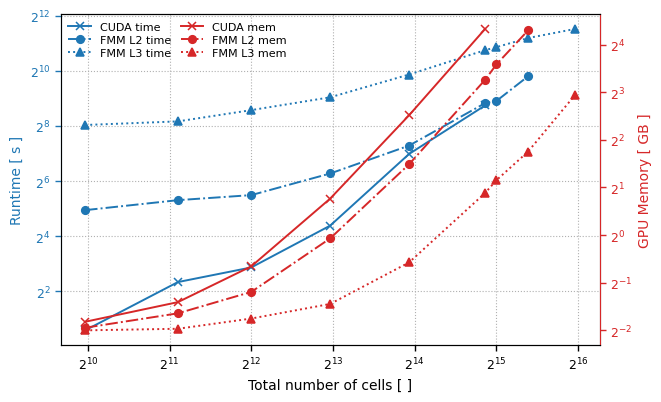

In [12]:

# ---- call it with your lists ----
plot_time_and_memory(
    base_resolutions,
    cuda_res_time, cuda_cpu_mem, cuda_gpu_mem,
    None, None, None,
    fmm_res_time_L2, fmm_cpu_mem_L2, fmm_gpu_mem_L2,
    fmm_res_time_L3, fmm_cpu_mem_L3, fmm_gpu_mem_L3,
    ignore_cpu_mem=True,
    fig_width_in=3.45*1.25*1.5,   # typical IEEE single column ~3.5"
    fig_height_in=3.45*0.75*1.5,  # square-ish
)

In [13]:

# # ---- call it with your lists ----
# plot_time_and_memory(
#     base_resolutions,
#     cuda_res_time, cuda_cpu_mem, cuda_gpu_mem,
#     fmm_res_time_L1, fmm_cpu_mem_L1, fmm_gpu_mem_L1,
#     fmm_res_time_L2, fmm_cpu_mem_L2, fmm_gpu_mem_L2,
#     fmm_res_time_L3, fmm_cpu_mem_L3, fmm_gpu_mem_L3,
#     ignore_cpu_mem=True,
#     fig_width_in=3.45*1.1*1.5,   # typical IEEE single column ~3.5"
#     fig_height_in=3.45*0.9*1.5,  # square-ish
# )

In [14]:
def estimate_near_neighbours(level: int, N: int) -> float:
    """
    Estimate the total number of near-field cell–cell interactions in a 3D FMM tree.

    Assumptions:
    ------------
    - The FMM tree is complete.
    - The N^3 cells are uniformly distributed over all 8^level leaf nodes.
    - Each leaf is assumed to contain the average number of cells:
          cells_per_leaf = N^3 / 8^level
    - Near-field interactions are counted using a 3×3×3 stencil:
        * Inner leaves  -> 27 neighbours
        * Face leaves   -> 18 neighbours
        * Edge leaves   -> 12 neighbours
        * Corner leaves ->  8 neighbours

    Notes:
    ------
    This provides a slight *upper bound* when N is not divisible by 2^level,
    since fractional leaf occupancies are treated as fully populated.
    This is often acceptable for memory and workload estimation.

    Returns:
    --------
    Estimated total number of near-field cell–cell interactions.
    """

    N_tot = N**3

    leaf_nodes = 8**level
    nodes_per_side = 2**level

    inner_nodes  = (nodes_per_side - 2)**3
    face_nodes   = 6 * (nodes_per_side - 2)**2
    edge_nodes   = 12 * (nodes_per_side - 2)
    corner_nodes = 8

    cells_per_leaf = N_tot / leaf_nodes

    inner_nbors  = inner_nodes  * cells_per_leaf * 27 * cells_per_leaf
    face_nbors   = face_nodes  * cells_per_leaf * 18 * cells_per_leaf
    edge_nbors   = edge_nodes  * cells_per_leaf * 12 * cells_per_leaf
    corner_nbors = corner_nodes * cells_per_leaf * 8  * cells_per_leaf
    tot_nbors = inner_nbors + face_nbors + edge_nbors + corner_nbors

    return tot_nbors


In [15]:
N = 32
precision="single"
bytes_per_number = 4 if precision == "single" else 8
N_comp = 6 # 6 field components 


def dense_GPU_mem(N):
    N_tot = N**3
    N_nbor = N_tot**2 # all-to-all for dense
    mem_bytes = N_nbor * N_comp * bytes_per_number
    mem_GB = mem_bytes / (1024.0**3)
    return mem_GB



def sparse_GPU_mem(N, level):
    N_tot = N**3

    N_nbor = estimate_near_neighbours(level=level, N=N)
    mem_bytes = N_nbor * N_comp * bytes_per_number # 
    mem_bytes = mem_bytes * 2 # also include cols for sparse
    mem_bytes = mem_bytes + N_tot * 2 * bytes_per_number # include row_start and row_end

    mem_GB = mem_bytes / (1024.0**3)

    return mem_GB



gpu_mem_cuda = dense_GPU_mem(N) 
print(f"N={N:d} dense GPU mem: {gpu_mem_cuda:.3f} GB")

level = 3
gpu_mem_fmm = sparse_GPU_mem(N, level=level) 
print(f"N={N:d} level={level:d} sparse GPU mem: {gpu_mem_fmm:.3f} GB (Upper mem bound)")

frac = gpu_mem_fmm / gpu_mem_cuda
print(f"FMM / CUDA GPU mem ratio: {frac:.5f}")

N=32 dense GPU mem: 24.000 GB
N=32 level=3 sparse GPU mem: 1.950 GB (Upper mem bound)
FMM / CUDA GPU mem ratio: 0.08125
